<a href="https://colab.research.google.com/github/jankotschy/Applied-AI-in-Transportation/blob/main/Assignment_2_Text_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os

# The path of the dataset
url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_4_Text_classification/Pakistani%20Traffic%20sentiment%20Analysis.csv'

# Load the data use the pandas
df = pd.read_csv(url)

# Display the data
df.head()

,Text,Sentiment
0,Adayala road is clear,0
1,Traffic jam from parbat rd to nazim-ud-din rd ...,1
2,Mandra is clear,0
3,Fort street is clear,0
4,"Mashriq Hotel towards Fawara Chowk, City Sadda...",1


There is an even number of positive and negative samples, but in each case, the number of unique samples is less than the number of samples for that class. That means the dataset has duplicate rows, and duplicate rows could bias a machine learning model. Use the following statements to delete the duplicate rows and check for balance again:

In [ ]:
# Delete the duplicate rows
df = df.drop_duplicates()

# Displaying the instances of each class
df.groupby('Sentiment').describe()

Text                                                               
          count unique                                                top freq
Sentiment                                                                     
0          1008   1008                              Adayala road is clear    1
1          1079   1079  Traffic jam from parbat rd to nazim-ud-din rd ...    1

The tasks for this part is use the grid search to:
1. Identify which vectorization method works the best or basically not much difference.
2. Identify which model, together with its corresponding hyperparameters, gives the best performance for traffic sentimental analysis.

## Grid search over every vectorizer / model combination

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, HashingVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay as cmd
import pandas as pd
import numpy as np

RANDOM_STATE = 0

x = df['Text']
y = df['Sentiment']
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_STATE
)

In [ ]:
# -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* Vectorizers -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
vectorizers = {
    'CountVectorizer': CountVectorizer(
        ngram_range=(1, 2), stop_words='english', min_df=20
    ),
    'HashingVectorizer': HashingVectorizer(
        ngram_range=(1, 2), n_features=200, alternate_sign=False
    ),
    'TfidfVectorizer': TfidfVectorizer(
        min_df=20,
        norm='l2',
        smooth_idf=True,
        use_idf=True,
        ngram_range=(1, 1),
        stop_words='english',
    ),
}

In [ ]:
# -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* Models -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
models = {
    'LogisticRegression': (
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        {'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']},
    ),
    'RandomForest': (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
        },
    ),
    'SVM': (
        SVC(probability=True),
        {'kernel': ['linear', 'rbf', 'poly'], 'C': [0.1, 1, 10]},
    ),
    'NaiveBayes': (
        BernoulliNB(),
        {'alpha': [0.1, 0.5, 1], 'force_alpha': [True, False]},
    ),
    'XGBoost': (
        XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE),
        {
            'learning_rate': [0.01, 0.1, 0.2],
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 4, 5],
        },
    ),
}

In [ ]:
# -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* Run all combinations -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*

results = []
fitted_estimators = {}


for vec_name, vectorizer in vectorizers.items():

    # fit the vectorizer on the training text and transform both splits
    x_train_vectorized = vectorizer.fit_transform(x_train)
    x_test_vectorized = vectorizer.transform(x_test)

    for model_name, (base_model, param_grid) in models.items():

        print(f'Running GridSearchCV for [{vec_name} + {model_name}] ...')

        grid_search = GridSearchCV(
            estimator=base_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1
        )
        grid_search.fit(x_train_vectorized, y_train)

        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(x_test_vectorized)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        results.append({
            'Vectorizer': vec_name,
            'Model': model_name,
            'Best Params': grid_search.best_params_,
            'CV Accuracy': grid_search.best_score_,
            'Test Accuracy': acc,
            'Test F1': f1,
        })

        fitted_estimators[(vec_name, model_name)] = {
            'vectorizer': vectorizer,
            'model': best_model,
        }

results_df = pd.DataFrame(results)
print(f'\nCompleted {len(results_df)} runs.')
results_df

Running GridSearchCV for [CountVectorizer + LogisticRegression] ...


Running GridSearchCV for [CountVectorizer + KNN] ...


Running GridSearchCV for [CountVectorizer + RandomForest] ...


Running GridSearchCV for [CountVectorizer + SVM] ...


Running GridSearchCV for [CountVectorizer + NaiveBayes] ...
Running GridSearchCV for [CountVectorizer + XGBoost] ...


...

Running GridSearchCV for [TfidfVectorizer + RandomForest] ...


Running GridSearchCV for [TfidfVectorizer + SVM] ...


Running GridSearchCV for [TfidfVectorizer + NaiveBayes] ...
Running GridSearchCV for [TfidfVectorizer + XGBoost] ...



Completed 18 runs.


,Vectorizer,Model,Best Params,CV Accuracy,Test Accuracy,Test F1
0,CountVectorizer,LogisticRegression,{'C': 1},0.949073,0.937799,0.934343
1,CountVectorizer,KNN,"{'n_neighbors': 9, 'weights': 'uniform'}",0.931701,0.961722,0.960199
2,CountVectorizer,RandomForest,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.956865,0.964115,0.963145
3,CountVectorizer,SVM,"{'C': 10, 'kernel': 'rbf'}",0.953871,0.956938,0.955446
4,CountVectorizer,NaiveBayes,"{'alpha': 1, 'force_alpha': True}",0.947874,0.942584,0.940299
5,CountVectorizer,XGBoost,"{'learning_rate': 0.2, 'max_depth': 3, 'n_esti...",0.954468,0.959330,0.958025
6,HashingVectorizer,LogisticRegression,{'C': 1},0.948476,0.956938,0.955882
7,HashingVectorizer,KNN,"{'n_neighbors': 9, 'weights': 'distance'}",0.940681,0.940191,0.939173
8,HashingVectorizer,RandomForest,"{'max_depth': 30, 'min_samples_leaf': 2, 'min_...",0.969445,0.964115,0.963325
9,HashingVectorizer,SVM,"{'C': 10, 'kernel': 'rbf'}",0.968850,0.983254,0.982885


## Results

In [ ]:
model_order = list(models.keys())
vectorizer_order = list(vectorizers.keys())

accuracy_table = results_df.pivot(index='Model', columns='Vectorizer', values='Test Accuracy')
accuracy_table = accuracy_table.reindex(index=model_order, columns=vectorizer_order)

f1_table = results_df.pivot(index='Model', columns='Vectorizer', values='Test F1')
f1_table = f1_table.reindex(index=model_order, columns=vectorizer_order)

print('Accuracy (rows = models, columns = vectorizers)')
display(accuracy_table.round(4).style.background_gradient(cmap='Blues', axis=None).format('{:.4f}'))

Accuracy (rows = models, columns = vectorizers)


Vectorizer,CountVectorizer,HashingVectorizer,TfidfVectorizer
Model,,,
LogisticRegression,0.9378,0.9569,0.9545
KNN,0.9617,0.9402,0.9330
RandomForest,0.9641,0.9641,0.9713
SVM,0.9569,0.9833,0.9593
NaiveBayes,0.9426,0.9306,0.9402
XGBoost,0.9593,0.9665,0.9545


In [ ]:
print('F1 score (rows = models, columns = vectorizers)')
display(f1_table.round(4).style.background_gradient(cmap='Greens', axis=None).format('{:.4f}'))

F1 score (rows = models, columns = vectorizers)


Vectorizer,CountVectorizer,HashingVectorizer,TfidfVectorizer
Model,,,
LogisticRegression,0.9343,0.9559,0.9531
KNN,0.9602,0.9392,0.9314
RandomForest,0.9631,0.9633,0.9706
SVM,0.9554,0.9829,0.9584
NaiveBayes,0.9403,0.9273,0.9380
XGBoost,0.9580,0.9660,0.9531


### Best combination

Best combination by F1 score:
  Vectorizer : HashingVectorizer
  Model      : SVM
  Best Params: {'C': 10, 'kernel': 'rbf'}
  Accuracy   : 0.9833
  F1 score   : 0.9829


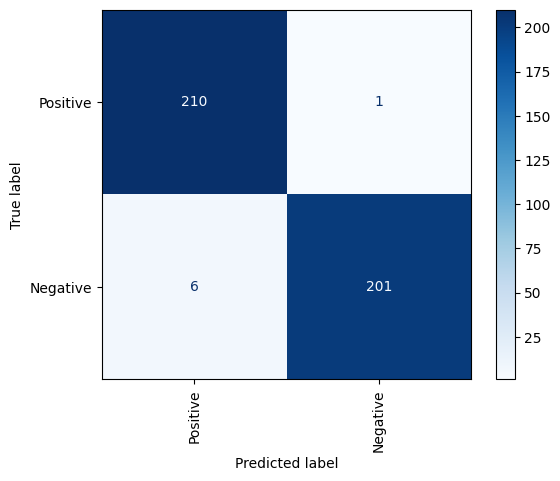

In [ ]:
best_row = results_df.loc[results_df['Test F1'].idxmax()]
print('Best combination by F1 score:')
print(f"  Vectorizer : {best_row['Vectorizer']}")
print(f"  Model      : {best_row['Model']}")
print(f"  Best Params: {best_row['Best Params']}")
print(f"  Accuracy   : {best_row['Test Accuracy']:.4f}")
print(f"  F1 score   : {best_row['Test F1']:.4f}")

best_vectorizer = fitted_estimators[(best_row['Vectorizer'], best_row['Model'])]['vectorizer']
best_model = fitted_estimators[(best_row['Vectorizer'], best_row['Model'])]['model']

cmd.from_estimator(
    best_model,
    best_vectorizer.transform(x_test),
    y_test,
    display_labels=['Positive', 'Negative'],
    cmap='Blues',
    xticks_rotation='vertical',
)

## Try the best model on a new sentence

In [ ]:
# Here you change the reviews
text = 'Adayala road is clear'

# Make a prediction for this review, using the best vectorizer + model found above
score = best_model.predict_proba(best_vectorizer.transform([text]))[0][1]

if score > 0.5:
    attitude = 'negative'
else:
    attitude = 'positive'

print('The prediction result of this review is: ' + attitude)

The prediction result of this review is: positive
